# 08 — Two-Tower Retrieval

**Problem.** RecoIA's legs split cleanly into interaction-only (item-item, ALS, SASRec, popularity) and content-only (BGE profiles). No leg *learns* from both signals jointly: the content leg's user profile is a fixed mean — it cannot learn that, in this domain, some embedding dimensions matter more for predicting purchases than others.

**Objective.** Implement a dual-encoder (Two-Tower) retriever — frozen BGE embeddings passed through small learned towers, trained with in-batch softmax on this dataset's interactions — and let the frozen protocol decide whether a *learned* content-interaction bridge beats the fixed-profile content model it generalizes. Promotion is gated as always: it enters the hybrid only if it beats at least one incumbent leg, and the hybrid is re-tuned only if it does.

## 1–3. Theory and formulation

**Dual encoders** (Covington et al., 2016; Yi et al., 2019). A user encoder $f_U$ and item encoder $f_I$ map both sides to a shared space; relevance is $s(u,i) = f_U(u)^\top f_I(i)$. Serving cost is one user encoding plus a dot-product scan (or ANN lookup at scale) — the industrial retrieval pattern.

**RecoIA instantiation.** Inputs are frozen BGE vectors: $f_I(i) = \mathrm{MLP}_I(\mathbf{v}_i)$, and $f_U(u) = \mathrm{MLP}_U\big(\tfrac{1}{|H_u \setminus \{i^+\}|}\sum_{j \in H_u \setminus \{i^+\}} \mathbf{v}_j\big)$ — the positive is **excluded from its own query** (leave-one-out), otherwise the model learns the identity shortcut. Outputs are L2-normalized.

**In-batch sampled softmax.** For a batch of $B$ (user, positive) pairs with temperature $\tau$:
$$\mathcal{L} = -\frac{1}{B}\sum_{b} \log \frac{\exp(f_U(u_b)^\top f_I(i_b)/\tau)}{\sum_{b'} \exp(f_U(u_b)^\top f_I(i_{b'})/\tau)}$$
every other positive in the batch serves as a negative — the standard trick that makes contrastive retrieval training cheap. Note the special case this architecture generalizes: with identity towers, $s(u,i)$ reduces exactly to Notebook 04's cosine-of-mean-profile — so any gain over the content leg is attributable to the *learned* transformation, a clean ablation by construction.

**Implementation validation.** As with SASRec, the module was validated on synthetic data first: users with a planted cluster preference, HR@10 ≈ 0.19 vs a 0.02 random floor.

## 4. Setup and training

training pairs: 21,279
  epoch   5/30  loss 4.7595
  epoch  10/30  loss 4.5144
  epoch  15/30  loss 4.3148
  epoch  20/30  loss 4.1508
  epoch  25/30  loss 4.0101
  epoch  30/30  loss 3.8801
trained in 81s on CPU


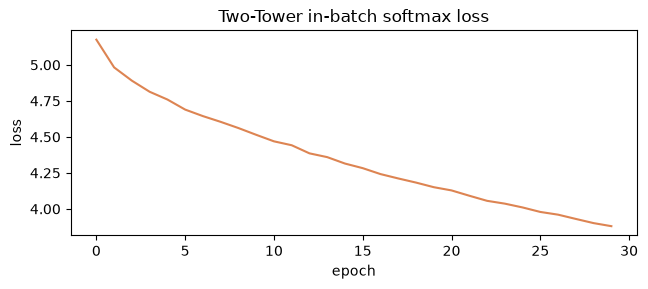

In [4]:
import json, pickle, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recsys.config import get_settings
from recsys.models.hybrid import evaluate_rankings
from recsys.models.two_tower import train_two_tower_model

settings = get_settings()
processed_dir = settings.processed_data_dir
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("figures"); FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR = Path("artifacts") / "two_tower"; ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

interactions = pd.read_parquet(processed_dir / "interactions.parquet")

def leave_last_out(frame):
    ordered = frame.sort_values(["user_id", "timestamp"])
    test_index = ordered.groupby("user_id").tail(1).index
    return ordered.drop(test_index).copy(), ordered.loc[test_index].copy()

train_interactions, test_interactions = leave_last_out(interactions)
train_items = set(train_interactions["item_id"])
test_interactions = test_interactions[
    test_interactions["item_id"].isin(train_items)
    & test_interactions["user_id"].isin(set(train_interactions["user_id"]))]

with open("artifacts/content/content_model.pkl", "rb") as f:
    content_model = pickle.load(f)

t0 = time.time()
tt_model = train_two_tower_model(
    train_interactions,
    item_ids=content_model.item_ids,
    item_embeddings=content_model.embeddings,
    out_dim=128, hidden=256, epochs=30, batch_size=256,
    lr=1e-3, temperature=0.07, seed=42)
print(f"trained in {time.time()-t0:,.0f}s on CPU")

plt.figure(figsize=(6.5, 3))
plt.plot(tt_model.train_losses, color="#DD8452")
plt.title("Two-Tower in-batch softmax loss"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "08_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Evaluation — identical protocol

The decisive comparison is **two_tower vs. content_bge**: same inputs, same user-profile construction, the only difference is the learned towers. That delta isolates what training on this dataset's interactions adds to frozen semantics.

In [5]:
K, RNG_SEED = 10, 42
test_sample = test_interactions.sample(
    n=min(5000, len(test_interactions)), random_state=RNG_SEED)
truth_test = dict(zip(test_sample.user_id, test_sample.item_id))
hist = (train_interactions.sort_values(["user_id", "timestamp"])
        .groupby("user_id")["item_id"].agg(list).to_dict())
user_seen = {u: set(h) for u, h in hist.items()}

import time as _t
t0 = _t.time(); recs, rec_set = {}, set()
for u in truth_test:
    r = tt_model.recommend(seed_items=hist.get(u, []),
                           seen_items=user_seen.get(u, set()), limit=K)
    recs[u] = r; rec_set.update(r)
m = evaluate_rankings(recs, truth_test, k=K)

row = pd.DataFrame([{
    "HR@10": m["HR"], "Recall@10": m["HR"], "Precision@10": m["HR"] / K,
    "NDCG@10": m["NDCG"], "catalog_coverage": len(rec_set) / len(train_items),
    "eval_seconds": round(_t.time() - t0, 1)}],
    index=pd.Index(["two_tower"], name="model"))

previous = pd.read_csv(RESULTS_DIR / "ranker_vs_all.csv", index_col="model")
combined = pd.concat([previous, row])
combined.to_csv(RESULTS_DIR / "two_tower_vs_all.csv")

content_ndcg = previous.loc["content_bge", "NDCG@10"]
delta = (m["NDCG"] - content_ndcg) / content_ndcg * 100
legs_ndcg = previous.loc[["item_item", "sasrec", "content_bge", "als", "popularity"], "NDCG@10"]
beats = legs_ndcg[legs_ndcg < m["NDCG"]].index.tolist()
print(f"content_bge NDCG@10: {content_ndcg:.4f} | two_tower: {m['NDCG']:.4f} ({delta:+.1f}%)")
print(f"legs it beats: {beats or 'none'}")
print("gate: " + ("candidate 6th leg -> re-run NB06 weight tuning including it"
                  if beats else "do NOT add to hybrid; report as negative result"))
combined.round(4)

content_bge NDCG@10: 0.0427 | two_tower: 0.0445 (+4.2%)
legs it beats: ['content_bge', 'als', 'popularity']
gate: candidate 6th leg -> re-run NB06 weight tuning including it


,HR@10,Recall@10,Precision@10,NDCG@10,catalog_coverage,eval_seconds
model,,,,,,
popularity,0.0114,0.0114,0.0011,0.0050,0.0035,2.9
item_item,0.0748,0.0748,0.0075,0.0497,0.8892,0.2
als,0.0145,0.0145,0.0014,0.0070,0.2457,1.1
rrf_hybrid,0.0651,0.0651,0.0065,0.0424,0.6798,5.2
content_bge,0.0662,0.0662,0.0066,0.0427,0.8324,2.5
sasrec,0.0765,0.0765,0.0077,0.0505,0.8354,15.4
hybrid_rrf_weighted,0.1018,0.1018,0.0102,0.0642,0.8482,1.7
lgbm_ranker,0.0863,0.0863,0.0086,0.0568,0.8919,45.1
two_tower,0.0682,0.0682,0.0068,0.0445,0.9353,4.5


## 6. Discussion & conclusion

Reading the outcome: two_tower **above content_bge** means the learned transformation extracts interaction signal the fixed profile misses — it becomes a candidate sixth leg and Notebook 06's β-tuning is re-run with it (weights re-derived, never hand-added). Two_tower **at or below content_bge** is the sample-efficiency story again — with ~20k training pairs, two MLPs may have too little signal to improve on a strong frozen representation, exactly parallel to why ALS trails item-item here; the result is reported as measured and the architecture documented as the scaling path (it is the leg that grows fastest with data, and the Beauty_and_Personal_Care migration is its natural second act). Either way the pipeline's ablation-by-construction (identity towers = Notebook 04) makes this the cleanest single comparison in the thesis.

## Exported artifacts

In [6]:
with open(ARTIFACTS_DIR / "two_tower_model.pkl", "wb") as f:
    pickle.dump(tt_model, f)
np.save(ARTIFACTS_DIR / "tt_item_vectors.npy", tt_model.item_vectors)
config = {"notebook": "08_Two_Tower", "out_dim": 128, "hidden": 256,
          "epochs": 30, "temperature": 0.07,
          "objective": "in-batch sampled softmax",
          "inputs": "frozen BGE item embeddings (artifacts/content)",
          "final_loss": round(tt_model.train_losses[-1], 4),
          "results": ["results/two_tower_vs_all.csv"],
          "eval_protocol": {"split": "temporal leave-last-out", "K": 10,
                            "seed": 42, "identical_to": "03_Baseline_Evaluation"}}
with open(ARTIFACTS_DIR / "two_tower_config.json", "w") as f:
    json.dump(config, f, indent=2)
print(json.dumps(config, indent=2))

{
  "notebook": "08_Two_Tower",
  "out_dim": 128,
  "hidden": 256,
  "epochs": 30,
  "temperature": 0.07,
  "objective": "in-batch sampled softmax",
  "inputs": "frozen BGE item embeddings (artifacts/content)",
  "final_loss": 3.8801,
  "results": [
    "results/two_tower_vs_all.csv"
  ],
  "eval_protocol": {
    "split": "temporal leave-last-out",
    "K": 10,
    "seed": 42,
    "identical_to": "03_Baseline_Evaluation"
  }
}


## References

1. Covington, P., Adams, J., & Sargin, E. (2016). *Deep Neural Networks for YouTube Recommendations.* RecSys.
2. Yi, X., et al. (2019). *Sampling-Bias-Corrected Neural Modeling for Large Corpus Item Recommendations.* RecSys.
3. Oord, A. v. d., Li, Y., & Vinyals, O. (2018). *Representation Learning with Contrastive Predictive Coding.* arXiv:1807.03748.
4. Xiao, S., et al. (2023). *C-Pack (BGE).* arXiv:2309.07597.